# 1.7 Datos geodésicos GNSS

Este cuaderno descarga series de tiempo diarias de posición GNSS del [Nevada Geodetic Laboratory](https://geodesy.unr.edu) (NGL) de la Universidad de Nevada, Reno. El NGL procesa datos de miles de estaciones GNSS permanentes en todo el mundo — incluidas las redes mexicanas — y publica soluciones diarias de posición como archivos de texto plano, un archivo por estación.

**Qué son los datos.** Una estación GNSS permanente mide su propia posición, cada día, a unos pocos milímetros. La serie de tiempo registra el movimiento del suelo: la deriva tectónica constante de las placas, los sismos (saltos repentinos), los eventos de deslizamiento lento (*slow slip events*) y la carga estacional de agua y nieve.

**Marco de referencia.** Usamos soluciones en **IGS20**, la realización vigente del Marco de Referencia Terrestre Internacional adoptada por el Servicio GNSS Internacional (IGS). Las posiciones se expresan respecto a este marco global, de modo que las tendencias constantes que verá son movimientos de placas.

**Citación.** Al usar productos del NGL, cite: Blewitt, G., Hammond, W. C., & Kreemer, C. (2018). Harnessing the GPS data explosion for interdisciplinary science. *Eos*, 99, [doi:10.1029/2018EO104623](https://doi.org/10.1029/2018EO104623).

🖥️ [**Diapositivas — Sesión 04 (mié 7 oct)**](https://geo-smart.github.io/mlgeo-book/slides/2026/lec04_meet_the_data.html)

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pooch

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

## El formato `.tenv3`

Cada archivo de estación en `https://geodesy.unr.edu/gps_timeseries/IGS20/tenv3/IGS20/{STATION}.tenv3` está delimitado por espacios, con una línea de encabezado. Las columnas incluyen el nombre de la estación (`site`), la fecha (`YYMMMDD`), el año decimal (`yyyy.yyyy`) y las componentes de posición divididas en una base entera y una parte fraccionaria: `__east(m)`, `_north(m)`, `____up(m)` contienen la parte variable de las posiciones este, norte y vertical, en metros. Los guiones bajos de aspecto extraño son parte de los nombres reales de las columnas, así que inspeccionamos el encabezado después de leer el archivo en lugar de suponerlo.

Usamos dos estaciones mexicanas con más de veinte años de soluciones diarias, ambas de la Red Geodésica Nacional Activa del INEGI y procesadas por el NGL: **OAX2**, en la ciudad de Oaxaca, sobre la zona de subducción donde la placa de Cocos se hunde bajo la placa de Norteamérica, y **MERI**, en Mérida, sobre la plataforma estable de Yucatán. El contraste entre ambas es la lección.

## Descargar con pooch — y por qué aquí no se fija el *hash*

La sección [1.6](1.6_data_gallery.md) enseñó el patrón: descargar con `pooch` y luego fijar la suma de verificación impresa como `known_hash`, para que cada ejecución futura verifique que recibió los mismos bytes. Ese patrón aplica a archivos **congelados** — un conjunto de datos publicado, una instantánea archivada, el ráster de Natural Earth del capítulo 2.2.

Estos archivos del NGL son **datos vivos**: cada día se agrega una nueva solución diaria, así que la suma de verificación del archivo cambia cada día, y un *hash* fijado hoy fallaría mañana — por diseño, porque el archivo realmente cambió. Por eso aquí pasamos `known_hash=None` y en cambio *imprimimos* el SHA256 de lo que en efecto recibimos. Ese *hash* impreso es su registro de procedencia: cópielo a sus notas o a su bitácora de ejecución, y el análisis de hoy queda atado a una entrada exacta aunque la descarga de mañana sea distinta. Si necesita reejecuciones idénticas bit a bit (un artículo, una entrega calificada), congele una instantánea — archive el archivo descargado (Zenodo, la *release* de datos de su repositorio) y fije el *hash* de *esa* copia.

Una advertencia sobre la caché: con `known_hash=None`, pooch reutiliza una copia en caché sin preguntarle al servidor. Borre el archivo `.tenv3` de `data/` cuando quiera los datos de hoy en lugar de los del día en que ejecutó este cuaderno por primera vez.

In [2]:
BASE_URL = "https://geodesy.unr.edu/gps_timeseries/IGS20/tenv3/IGS20/{station}.tenv3"


def fetch_tenv3(station):
    """Fetch an NGL .tenv3 daily position file (cached by pooch) as a DataFrame."""
    path = pooch.retrieve(
        url=BASE_URL.format(station=station),
        known_hash=None,  # living data: NGL appends a new daily solution every day
        fname=f"{station}.tenv3",
        path=DATA_DIR,
        downloader=pooch.HTTPDownloader(timeout=120),
    )
    print(f"{station}.tenv3 sha256:{pooch.file_hash(path)}")
    # whitespace-delimited text with one header line
    return pd.read_csv(path, sep=r"\s+")


df = fetch_tenv3("OAX2")
print(df.columns.tolist())

SHA256 hash of downloaded file: 95c7e632c238be4778155e5e4ead1e0900f625600465ee15f0de979ff7a0e05d
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


OAX2.tenv3 sha256:95c7e632c238be4778155e5e4ead1e0900f625600465ee15f0de979ff7a0e05d
['site', 'YYMMMDD', 'yyyy.yyyy', '__MJD', 'week', 'd', 'reflon', '_e0(m)', '__east(m)', '____n0(m)', '_north(m)', 'u0(m)', '____up(m)', '_ant(m)', 'sig_e(m)', 'sig_n(m)', 'sig_u(m)', '__corr_en', '__corr_eu', '__corr_nu', '_latitude(deg)', '_longitude(deg)', '__height(m)']


In [3]:
df.head()

,site,YYMMMDD,yyyy.yyyy,__MJD,week,d,reflon,_e0(m),__east(m),____n0(m),...,_ant(m),sig_e(m),sig_n(m),sig_u(m),__corr_en,__corr_eu,__corr_nu,_latitude(deg),_longitude(deg),__height(m)
0,OAX2,03MAR01,2003.1622,52699,1207,6,-96.7,-1781,-0.750025,1888976,...,0.1317,0.001085,0.000915,0.004268,-0.011081,0.051686,-0.006578,17.07834,-96.716739,1607.25291
1,OAX2,03MAR02,2003.1650,52700,1208,0,-96.7,-1781,-0.749275,1888976,...,0.1317,0.001071,0.000952,0.004370,-0.037510,0.084256,0.001364,17.07834,-96.716739,1607.24336
2,OAX2,03MAR03,2003.1677,52701,1208,1,-96.7,-1781,-0.750381,1888976,...,0.1317,0.001144,0.000942,0.004602,-0.053324,0.122491,-0.087639,17.07834,-96.716739,1607.24971
3,OAX2,03MAR04,2003.1704,52702,1208,2,-96.7,-1781,-0.749913,1888976,...,0.1317,0.001107,0.000955,0.004392,-0.028907,0.036570,0.079246,17.07834,-96.716739,1607.25167
4,OAX2,03MAR05,2003.1732,52703,1208,3,-96.7,-1781,-0.749517,1888976,...,0.1317,0.001064,0.000953,0.004291,0.038343,0.027875,0.098365,17.07834,-96.716739,1607.25045


## Desplazamiento relativo

Las coordenadas absolutas son números grandes; lo que nos importa es el movimiento. Restamos la primera solución diaria de cada componente, de modo que cada serie empieza en cero y muestra el desplazamiento en metros desde la primera observación. Conservamos el año decimal como eje de tiempo.

In [4]:
def to_relative(df):
    """Return decimal year and east/north/up displacement (m) relative to the first epoch."""
    return pd.DataFrame(
        {
            "decimal_year": df["yyyy.yyyy"],
            "east_m": df["__east(m)"] - df["__east(m)"].iloc[0],
            "north_m": df["_north(m)"] - df["_north(m)"].iloc[0],
            "up_m": df["____up(m)"] - df["____up(m)"].iloc[0],
        }
    )


rel_p395 = to_relative(df)
rel_p395.describe()

,decimal_year,east_m,north_m,up_m
count,7540.000000,7540.000000,7540.000000,7540.000000
mean,2016.052509,-0.075139,0.002636,0.000606
std,6.078913,0.043254,0.025251,0.017351
min,2003.162200,-0.147413,-0.043408,-0.039106
25%,2010.893225,-0.116352,-0.029237,-0.010596
50%,2016.091700,-0.074581,0.011633,-0.000152
75%,2021.317575,-0.028746,0.022846,0.008205
max,2026.486000,0.002762,0.037943,0.145477


In [5]:
# download both stations and save the relative positions to ./data/
stations = ["OAX2", "MERI"]
series = {}
for station in stations:
    rel = to_relative(fetch_tenv3(station))
    outfile = DATA_DIR / f"gps_{station}_relative_position.csv"
    rel.to_csv(outfile, index=False)
    series[station] = rel
    print(f"{station}: {len(rel)} daily solutions saved to {outfile}")

OAX2.tenv3 sha256:95c7e632c238be4778155e5e4ead1e0900f625600465ee15f0de979ff7a0e05d
OAX2: 7540 daily solutions saved to data/gps_OAX2_relative_position.csv


SHA256 hash of downloaded file: 9f2e2e503a18167932de4bbfe81278997be2d55e3f2b75ea97f3303bef66cffb
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


MERI.tenv3 sha256:9f2e2e503a18167932de4bbfe81278997be2d55e3f2b75ea97f3303bef66cffb
MERI: 7495 daily solutions saved to data/gps_MERI_relative_position.csv


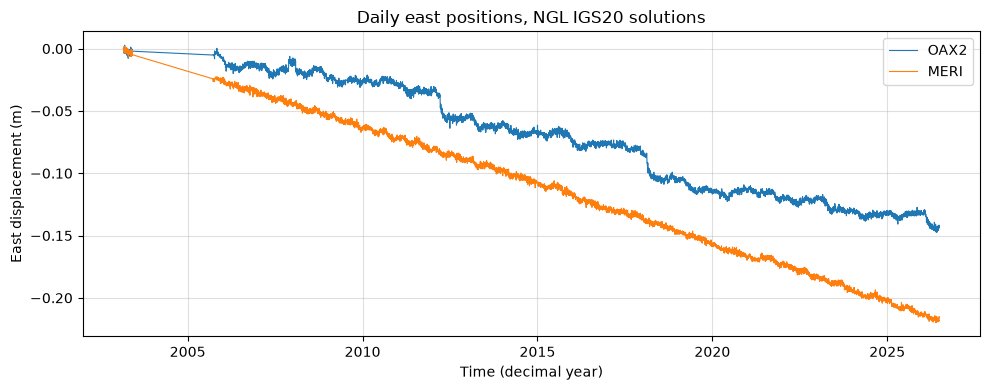

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
for station, rel in series.items():
    ax.plot(rel["decimal_year"], rel["east_m"], lw=0.8, label=station)
ax.set_xlabel("Time (decimal year)")
ax.set_ylabel("East displacement (m)")
ax.set_title("Daily east positions, NGL IGS20 solutions")
ax.grid(alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()

Las componentes este muestran la deriva de la placa de Norteamérica en el marco IGS20: cerca de 1 cm por año hacia el oeste, la tectónica de placas medida directamente. En **MERI**, sobre la plataforma estable de Yucatán, esa recta con pequeñas ondulaciones estacionales es casi toda la historia. **OAX2** cuenta una más rica: su serie se aparta de la línea recta en escalones y cambios de pendiente — la deformación del ciclo sísmico de la subducción mexicana, donde se superponen sismos y eventos de deslizamiento lento.

Los sismos están en los datos que usted acaba de descargar, más claros en la componente norte que en la este: el sismo de Tehuantepec del 8 de septiembre de 2017 (M8.2) desplazó OAX2 cerca de 1 cm hacia el sur en un día, y el sismo de Oaxaca del 23 de junio de 2020 (M7.4, cerca de La Crucecita) la desplazó casi 2 cm más. Grafique la columna `north_m` del CSV de OAX2 y busque los escalones en 2017.7 y 2020.5 — un salto cosísmico real, en una estación operada en México, con el mismo cargador de datos. En capítulos posteriores este tipo de serie se convierte en insumo para ejercicios de estimación de tendencias, descomposición estacional y pronóstico.

Los archivos CSV guardados en `./data/` contienen solo el año decimal y las tres componentes de desplazamiento, listos para reutilizarse.

**Crédito de los datos:** Nevada Geodetic Laboratory (Blewitt et al., 2018, doi:10.1029/2018EO104623); estaciones OAX2 y MERI de la Red Geodésica Nacional Activa del INEGI (México). Los datos se distribuyen abiertamente; cite al NGL en todo lo que publique a partir de ellos.